/home/r/Robert.Reichert/.conda/envs/JuWavelet/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


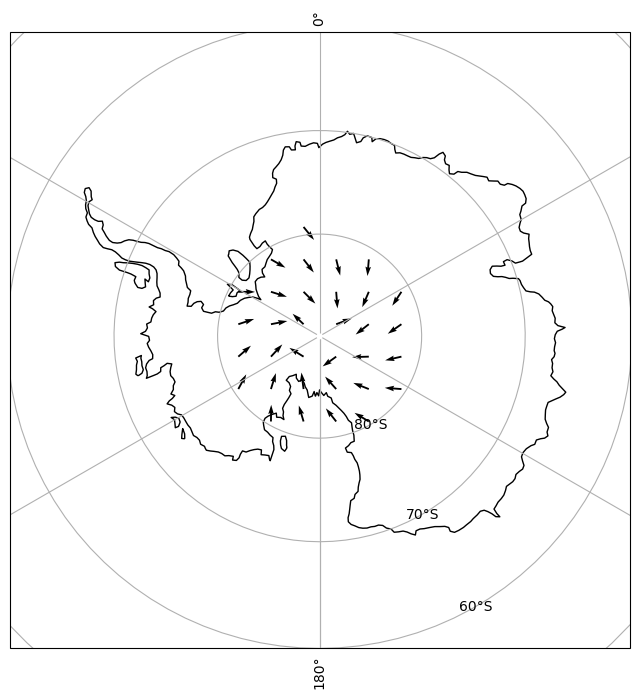

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# --- Beispieldaten: ersetze durch deine echten AIRS lat/lon und Vektoren ---
# lat, lon: Arrays der Form (NTRACK, NXTRACK) — deine Geolokalisierung
# u_track, u_xtrack: deine Vektorkomponenten im Satellitensystem, gleiche Form

# ---- Dummy-Daten zur Demonstration (Swath nahe Südpol) ----
ntrack, nxtrack = 40, 30
track_idx = np.linspace(0, 10, ntrack)
xtrack_idx = np.linspace(-1, 1, nxtrack)
TT, XX = np.meshgrid(track_idx, xtrack_idx, indexing='ij')

lat = -90 + 8 * np.abs(XX) + 0.3 * TT          # Beispielhafte Swath-Geometrie
lon = 100 + 15 * TT + 40 * XX                   # nahe des Pols "verzerrt" sich lon stark

u_track  = np.ones_like(lat) * 5.0    # z.B. 5 m/s entlang Flugrichtung
u_xtrack = np.ones_like(lat) * 2.0    # z.B. 2 m/s quer zur Flugrichtung

# --- Schritt 1: lokalen Heading-Winkel (Bearing) berechnen ---
def bearing(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, (lat1, lon1, lat2, lon2))
    dlon = lon2 - lon1
    x = np.sin(dlon) * np.cos(lat2)
    y = np.cos(lat1) * np.sin(lat2) - np.sin(lat1) * np.cos(lat2) * np.cos(dlon)
    return np.arctan2(x, y)   # Winkel im Bogenmaß, im Uhrzeigersinn ab Nord

theta = np.empty_like(lat)
theta[:-1, :] = bearing(lat[:-1, :], lon[:-1, :], lat[1:, :], lon[1:, :])
theta[-1, :] = theta[-2, :]   # letzte Zeile: Winkel der vorletzten übernehmen

# --- Schritt 2: Rotation der Vektorkomponenten ins Ost/Nord-System ---
# ACHTUNG: Vorzeichen von u_xtrack-Anteil hängt von der Scan-Richtung deines
# Instruments ab (ob NXTRACK nach rechts oder links der Flugrichtung zählt).
# Am besten an einem bekannten Fall verifizieren!
u_east  = u_track * np.sin(theta) + u_xtrack * np.cos(theta)
v_north = u_track * np.cos(theta) - u_xtrack * np.sin(theta)

# --- Schritt 3: Plot mit stereographischer Projektion ---
proj = ccrs.SouthPolarStereo()
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': proj})
ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())
ax.coastlines(resolution='110m')
ax.gridlines(draw_labels=True)

# regrid_shape dünnt das Feld aus, sonst ist es bei vielen Pixeln zu dicht
ax.quiver(lon, lat, u_east, v_north,
          transform=ccrs.PlateCarree(),
          regrid_shape=20,
          scale=200)   # scale ggf. an deine Werte anpassen

plt.show()

In [1]:
import sys
sys.path.append('/home/r/Robert.Reichert/WAVEGUIDE_campaign/ripple')
import ripple.coordinate_juggling as cj

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

/home/r/Robert.Reichert/.conda/envs/JuWavelet/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [13]:
def get_track_unit_vectors(lat, lon):
    """
    lat, lon: 2D arrays oder 1D arrays entlang des Tracks
    Erwartung: along-track ist Achse 0
    Rückgabe:
        e_along_east, e_along_north,
        e_across_east, e_across_north
    """

    lat = np.asarray(lat, dtype=float)
    lon = np.asarray(lon, dtype=float)

    lat_rad = np.deg2rad(lat)
    lon_rad = np.unwrap(np.deg2rad(lon))

    # zentrale Differenzen entlang along-track
    dlat = np.zeros_like(lat_rad)
    dlon = np.zeros_like(lon_rad)

    dlat[1:-1] = lat_rad[2:] - lat_rad[:-2]
    dlon[1:-1] = lon_rad[2:] - lon_rad[:-2]

    # Ränder: einfache Differenzen
    dlat[0] = lat_rad[1] - lat_rad[0]
    dlat[-1] = lat_rad[-1] - lat_rad[-2]
    dlon[0] = lon_rad[1] - lon_rad[0]
    dlon[-1] = lon_rad[-1] - lon_rad[-2]

    dx = np.cos(lat_rad) * dlon   # East
    dy = dlat                     # North

    norm = np.hypot(dx,dy)
    norm[norm == 0] = np.nan

    e_along_e = dx / norm
    e_along_n = dy / norm

    # 90° gegen den Uhrzeigersinn:
    # positive Across-Track-Richtung liegt links der Flugrichtung
    e_across_e = -e_along_n
    e_across_n =  e_along_e

    return e_along_e, e_along_n, -e_across_e, -e_across_n


def rotate_wave_vector(k_across, k_along, lat, lon):
    e_along_e, e_along_n, e_across_e, e_across_n = get_track_unit_vectors(lat, lon)

    k_east  = k_across * e_across_e + k_along * e_along_e
    k_north = k_across * e_across_n + k_along * e_along_n

    return k_east, k_north

In [3]:
NTRACK   = np.linspace(0,19,20)
NXTRACK  = np.linspace(0,9,10)
XX, YY   = np.meshgrid(NTRACK, NXTRACK)
k_across = XX*0+2e-5 #[rad/m]
k_along  = XX*0+1e-5 #[rad/m]
dx, dy   = 50_000, 50_000 #[m]
lon0, lat0 = 100, -88

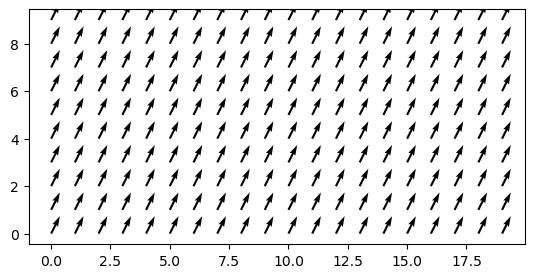

In [4]:
fig=plt.figure()
ax=fig.add_subplot()
ax.quiver(XX,YY,k_along,k_across)
ax.set_aspect("equal")

In [5]:
k_across_da = xr.DataArray(k_across,
    coords={'y': NXTRACK*dy, 'x': NTRACK*dx},
    dims=['y','x'],
    attrs={'lon0': lon0, 'lat0': lat0})
k_across_geo = cj.xy_to_latlon(k_across_da)

k_along_da = xr.DataArray(k_along,
    coords={'y': NXTRACK*dy, 'x': NTRACK*dx},
    dims=['y','x'],
    attrs={'lon0': lon0, 'lat0': lat0})
k_along_geo = cj.xy_to_latlon(k_along_da)

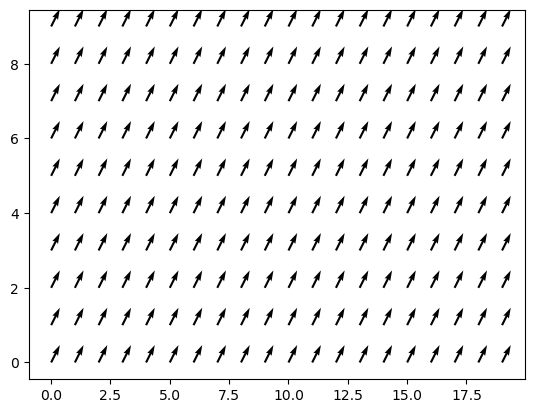

In [6]:
fig=plt.figure()
ax=fig.add_subplot()
ax.quiver(XX, YY, k_along_geo.values, k_across_geo.values)

(-90.0, -80.0)

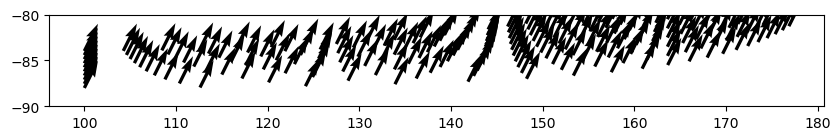

In [7]:
fig=plt.figure(figsize=(10,10))
ax=fig.add_subplot()
ax.quiver(k_across_geo.lon, k_across_geo.lat, k_along_geo.values, k_across_geo.values)
ax.set_aspect("equal")
ax.set_ylim([-90,-80])

In [14]:
e_along_e, e_along_n, e_across_e, e_across_n = get_track_unit_vectors(k_along_geo.lat.values,k_along_geo.lon.values)

(-90.0, -80.0)

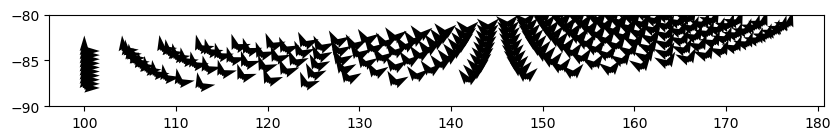

In [15]:
fig=plt.figure(figsize=(10,10))
ax=fig.add_subplot()
ax.quiver(k_across_geo.lon, k_across_geo.lat, e_along_e, e_along_n, scale=50)
ax.quiver(k_across_geo.lon, k_across_geo.lat, e_across_e, e_across_n, scale=50)
ax.set_aspect("equal")
ax.set_ylim([-90,-80])

In [16]:
k_east, k_north = rotate_wave_vector(k_across_geo.values, k_along_geo.values, k_along_geo.lat.values, k_along_geo.lon.values)

(-90.0, -80.0)

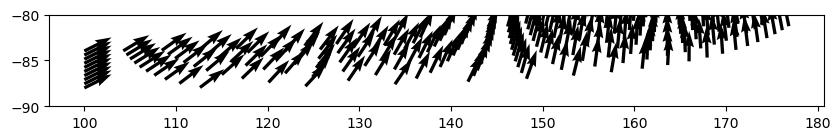

In [17]:
fig=plt.figure(figsize=(10,10))
ax=fig.add_subplot()
ax.quiver(k_across_geo.lon, k_across_geo.lat, k_east, k_north)
ax.set_aspect("equal")
ax.set_ylim([-90,-80])

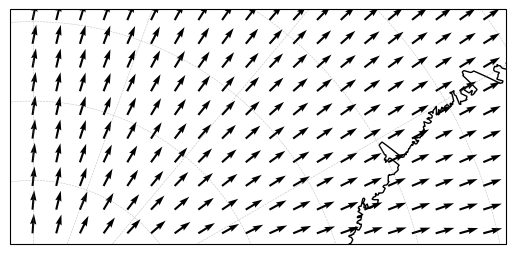

In [18]:
proj = ccrs.Stereographic(central_longitude=lon0, central_latitude=lat0)
data_crs = ccrs.PlateCarree()

fig=plt.figure()
ax=fig.add_subplot(projection=proj)
ax.coastlines()
gl = ax.gridlines(draw_labels=False, linewidth=0.4, color="gray", alpha=0.5, linestyle="--")
#ax.set_extent([90,150,-90,-83],crs=data_crs)
#ax.quiver(k_across_geo.lon.values, k_across_geo.lat.values, e_along_e, e_along_n, transform=data_crs, scale=20)
#ax.quiver(k_across_geo.lon.values, k_across_geo.lat.values, e_across_e, e_across_n, transform=data_crs, scale=20)
ax.quiver(k_along_geo.lon.values, k_along_geo.lat.values, k_east, k_north, transform=data_crs)

In [61]:
import numpy as np
from pyproj import CRS, Transformer, Geod

def wavevector_aeqd_to_enu(kx, ky, x, y, lon0, lat0, h=1000.0):
    """
    Transformiert einen Wellenvektor aus AEQD-Koordinaten (kx, ky)
    in lokale Ost-/Nord-Komponenten.

    Parameter
    ---------
    kx, ky : array-like
        Wellenzahlkomponenten bezüglich der AEQD-Koordinaten x und y [rad/m].
    x, y : 1D oder 2D array-like
        AEQD-Koordinaten in Metern.
    lon0, lat0 : float
        Projektionszentrum.
    h : float
        Schrittweite für die numerische Bestimmung des Jacobians [m].

    Rückgabe
    --------
    lon, lat, k_east, k_north
    """

    x, y = np.asarray(x, float), np.asarray(y, float)

    if x.ndim == 1 and y.ndim == 1:
        X, Y = np.meshgrid(x, y)
    else:
        X, Y = np.broadcast_arrays(x, y)

    kx, ky = np.broadcast_arrays(np.asarray(kx, float), np.asarray(ky, float))

    aeqd = CRS.from_proj4(
        f"+proj=aeqd +lat_0={lat0} +lon_0={lon0} "
        "+datum=WGS84 +units=m +no_defs"
    )
    #geographic = CRS.from_epsg(4326)
    geographic = CRS.from_proj4(
        "+proj=longlat +datum=WGS84 +no_defs"
    )
    transformer = Transformer.from_crs(aeqd, geographic, always_xy=True)
    geod = Geod(ellps="WGS84")

    lon, lat = transformer.transform(X, Y)

    def relative_enu(lon_neighbour, lat_neighbour):
        azimuth, _, distance = geod.inv(lon, lat, lon_neighbour, lat_neighbour)
        azimuth = np.deg2rad(azimuth)

        east = distance * np.sin(azimuth)
        north = distance * np.cos(azimuth)

        return east, north

    # Nachbarpunkte in positiver und negativer x-Richtung
    lon_xp, lat_xp = transformer.transform(X + h, Y)
    lon_xm, lat_xm = transformer.transform(X - h, Y)

    ex_p, nx_p = relative_enu(lon_xp, lat_xp)
    ex_m, nx_m = relative_enu(lon_xm, lat_xm)

    de_dx = (ex_p - ex_m) / (2 * h)
    dn_dx = (nx_p - nx_m) / (2 * h)

    # Nachbarpunkte in positiver und negativer y-Richtung
    lon_yp, lat_yp = transformer.transform(X, Y + h)
    lon_ym, lat_ym = transformer.transform(X, Y - h)

    ey_p, ny_p = relative_enu(lon_yp, lat_yp)
    ey_m, ny_m = relative_enu(lon_ym, lat_ym)

    de_dy = (ey_p - ey_m) / (2 * h)
    dn_dy = (ny_p - ny_m) / (2 * h)

    # A = [[de/dx, de/dy],
    #      [dn/dx, dn/dy]]
    det = de_dx * dn_dy - de_dy * dn_dx

    # k_EN = A^(-T) k_xy
    k_east  = ( dn_dy * kx - dn_dx * ky) / det
    k_north = (-de_dy * kx + de_dx * ky) / det

    return lon, lat, k_east, k_north

In [73]:
NTRACK   = np.linspace(0,11,12)
NXTRACK  = np.linspace(0,9,10)
XX, YY   = np.meshgrid(NTRACK, NXTRACK)
k_across = XX*0 #[rad/m]
k_along  = XX*0+1e-5 #[rad/m]
dx, dy   = 50_000, 50_000 #[m]
lon0, lat0 = 100, -88

In [74]:
lon, lat, k_east, k_north = wavevector_aeqd_to_enu(kx=k_along, ky=k_across, x=NTRACK*dx, y=NXTRACK*dy, lon0=lon0, lat0=lat0)

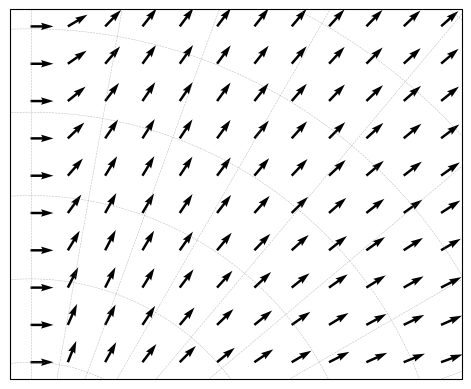

In [75]:
proj = ccrs.Stereographic(
    central_longitude=lon0,
    central_latitude=lat0
)
data_crs = ccrs.PlateCarree()

fig = plt.figure()
ax = fig.add_subplot(projection=proj)

ax.coastlines()
ax.gridlines(
    draw_labels=False,
    linewidth=0.4,
    color="gray",
    alpha=0.5,
    linestyle="--"
)

ax.quiver(
    lon, lat,
    k_east, k_north,
    transform=data_crs,
    angles="uv",
    scale_units="inches",
)

plt.show()